In [1]:
import pandas as pd
import sys

import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.multioutput import MultiOutputRegressor

sys.path.append('..')
from tool import Tool


In [2]:
# Load the datasets
DF_orig = pd.read_csv("../resources/district_data.csv")
DF_orig

,postcodeDistrict,catsPerHousehold,dogsPerHousehold,pre_1900,1900_1929,1930_1945,1945_1964,1965_1982,1983_1999,2000_present,unknown
0,AB10,0.164463,0.188610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AB11,0.206145,0.236411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AB12,0.300306,0.344397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AB13,1.145815,1.314045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AB14,1.008732,1.156835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2825,YO8,0.261034,0.299359,0.149670,0.083883,0.05,0.104744,0.198599,0.227873,0.166795,0.018437
2826,ZE1,0.454124,0.520799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2827,ZE2,0.677350,0.776799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2828,ZE3,0.458550,0.525875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
DF_orig.describe()

,catsPerHousehold,dogsPerHousehold,pre_1900,1900_1929,1930_1945,1945_1964,1965_1982,1983_1999,2000_present,unknown
count,2830.000000,2830.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000,2192.000000
mean,0.451960,0.518317,0.197530,0.093760,0.089460,0.156591,0.188545,0.134426,0.123103,0.016940
std,0.401342,0.460267,0.137016,0.080593,0.082045,0.092562,0.093559,0.070138,0.087549,0.014736
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001038,0.000000,0.000000
25%,0.196758,0.225646,0.088863,0.041339,0.039932,0.097671,0.131608,0.089665,0.074845,0.007158
50%,0.340893,0.390943,0.177686,0.071460,0.064075,0.143455,0.178422,0.125280,0.104807,0.013366
75%,0.592085,0.679015,0.278141,0.117104,0.110842,0.195879,0.233717,0.166175,0.145219,0.023166
max,5.212126,5.977375,0.894778,0.690773,0.701673,0.902367,0.876133,0.903670,0.884430,0.222222


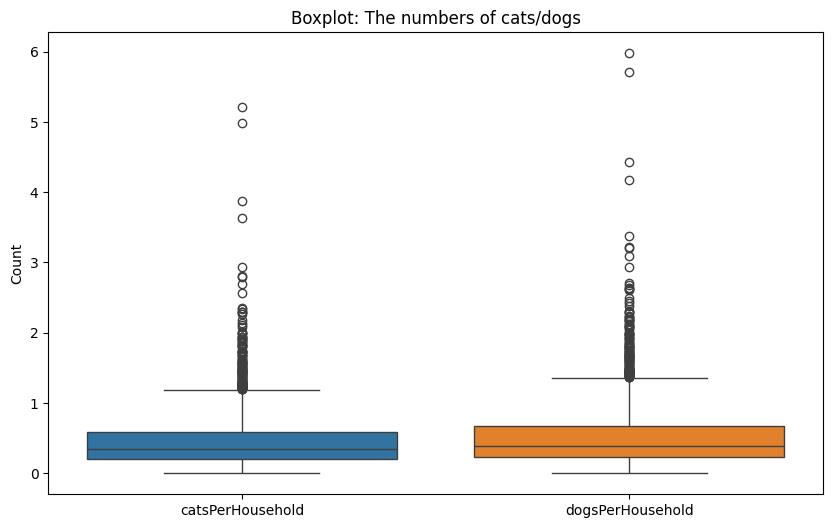

In [4]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=DF_orig[['catsPerHousehold', 'dogsPerHousehold']])
plt.title('Boxplot: The numbers of cats/dogs')
plt.ylabel('Count')
plt.show()

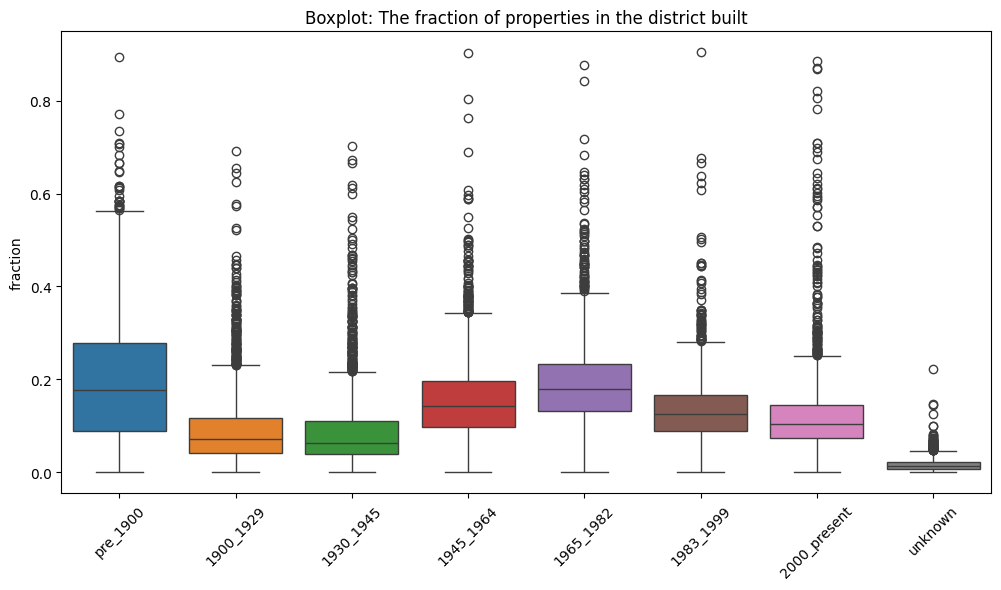

In [5]:
plt.figure(figsize=(12, 6))
year_cols = ['pre_1900', '1900_1929', '1930_1945', '1945_1964', '1965_1982', '1983_1999', '2000_present', 'unknown']
sns.boxplot(data=DF_orig[year_cols])
plt.title('Boxplot: The fraction of properties in the district built')
plt.xticks(rotation=45)
plt.ylabel('fraction')
plt.show()

In [6]:
def handle_outlier_iqr(df, col):
    # Calculate the first quartile (Q1) and third quartile (Q3)
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    # Calculate the interquartile range (IQR)
    iqr = q3 - q1
    # Determine the lower and upper bounds for non-outlier values
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    # Cap outliers by replacing values beyond bounds with the bounds themselves
    df[col] = df[col].clip(lower=lower, upper=upper)
    return df

# List of numeric columns that need outlier handling
cols_to_handle = ['catsPerHousehold', 'dogsPerHousehold', 
                  'pre_1900', '1900_1929', '1930_1945', 
                  '1945_1964', '1965_1982', '1983_1999', 
                  '2000_present', 'unknown']
# Create a copy of the original DataFrame to avoid modifying the source data
DF_cleaned = DF_orig.copy()
# Apply the IQR outlier handling to each target column
for col in cols_to_handle:
    DF_cleaned = handle_outlier_iqr(DF_cleaned, col)

DF_cleaned

,postcodeDistrict,catsPerHousehold,dogsPerHousehold,pre_1900,1900_1929,1930_1945,1945_1964,1965_1982,1983_1999,2000_present,unknown
0,AB10,0.164463,0.188610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AB11,0.206145,0.236411,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AB12,0.300306,0.344397,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AB13,1.145815,1.314045,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AB14,1.008732,1.156835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
2825,YO8,0.261034,0.299359,0.149670,0.083883,0.05,0.104744,0.198599,0.227873,0.166795,0.018437
2826,ZE1,0.454124,0.520799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2827,ZE2,0.677350,0.776799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2828,ZE3,0.458550,0.525875,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


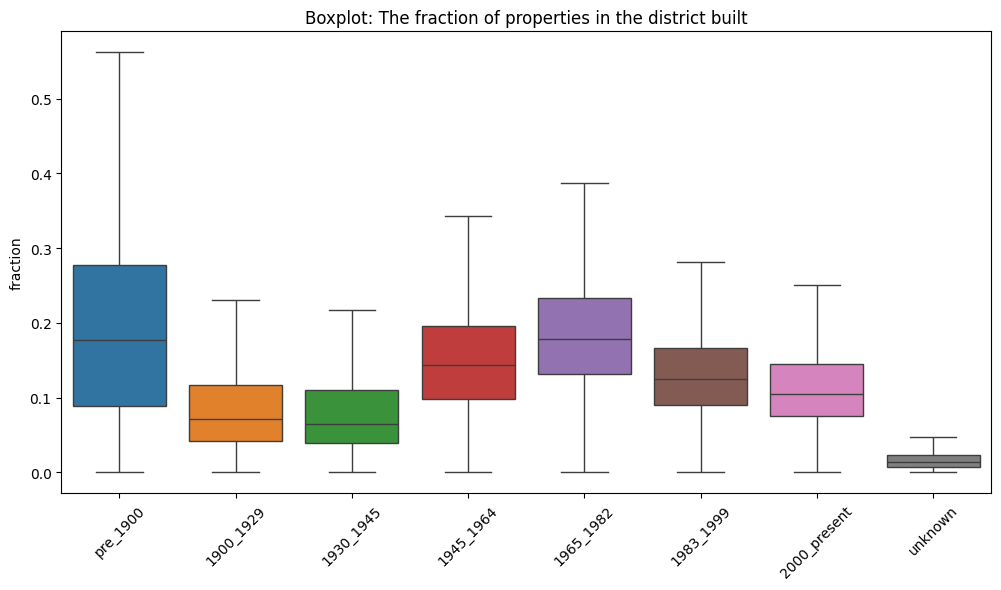

In [7]:
plt.figure(figsize=(12, 6))
year_cols = ['pre_1900', '1900_1929', '1930_1945', '1945_1964', '1965_1982', '1983_1999', '2000_present', 'unknown']
sns.boxplot(data=DF_cleaned[year_cols])
plt.title('Boxplot: The fraction of properties in the district built')
plt.xticks(rotation=45)
plt.ylabel('fraction')
plt.show()

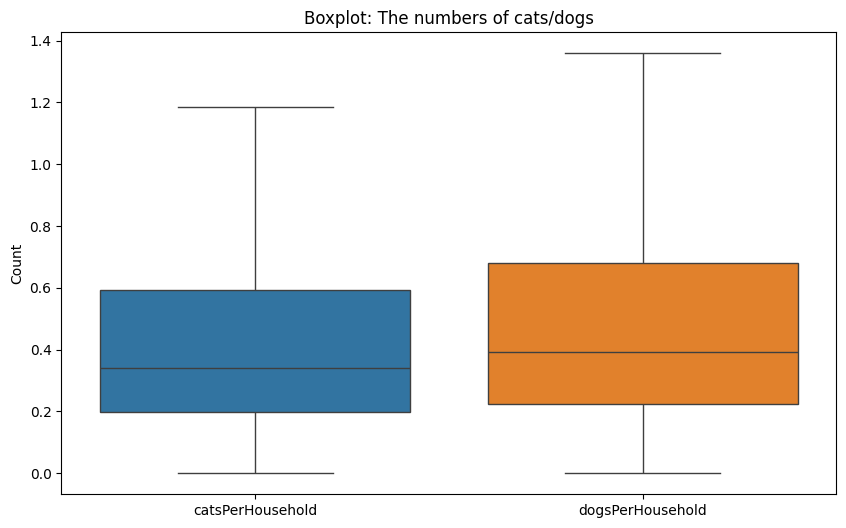

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=DF_cleaned[['catsPerHousehold', 'dogsPerHousehold']])
plt.title('Boxplot: The numbers of cats/dogs')
plt.ylabel('Count')
plt.show()

In [9]:
DF_cleaned.isnull().sum()

postcodeDistrict      0
catsPerHousehold      0
dogsPerHousehold      0
pre_1900            638
1900_1929           638
1930_1945           638
1945_1964           638
1965_1982           638
1983_1999           638
2000_present        638
unknown             638
dtype: int64

In [10]:
# # Define the columns representing property age groups
# targets = ['pre_1900', '1900_1929', '1930_1945', '1945_1964', '1965_1982', '1983_1999', '2000_present', 'unknown']

# # Split into training set (rows with non-null property age data)
# DF_train = DF_cleaned.dropna(subset=targets, how='all')

# DF_train

In [11]:
# # Split into test set (rows with all null property age data, to be predicted)
# DF_test = DF_cleaned[DF_cleaned[targets].isna().all(axis=1)]

# DF_test

In [12]:
# # Define features (pet counts) and targets (property age groups)
# features = ['catsPerHousehold', 'dogsPerHousehold']

# # Initialize a multi-output regression model (using RandomForest as the base estimator)
# model = MultiOutputRegressor(RandomForestRegressor(random_state=42))

# # Train the model on training data
# model.fit(DF_train[features], DF_train[targets])

# # Predict property age values for the test set
# predictions = model.predict(DF_test[features])

# # Convert predictions to a DataFrame and align with the original index
# DF_test_pred = pd.DataFrame(predictions, columns=targets, index=DF_test.index)

# # Calculate the sum of each row
# row_sums = DF_test_pred.sum(axis=1)

# # Divide the elements of each row by the sum of the row to achieve normalization
# DF_test_pred = DF_test_pred.div(row_sums, axis=0)

# # Fill the predicted values back into the original DataFrame
# DF_cleaned.loc[DF_test.index, targets] = DF_test_pred

We started with a step-by-step approach and now we have an interface

In [13]:
tool = Tool()
DF_cleaned = tool.impute_district_property_age(DF_cleaned)

In [14]:
DF_cleaned

,postcodeDistrict,catsPerHousehold,dogsPerHousehold,pre_1900,1900_1929,1930_1945,1945_1964,1965_1982,1983_1999,2000_present,unknown
0,AB10,0.164463,0.188610,0.180570,0.188600,0.141904,0.095248,0.106755,0.148880,0.134123,0.003920
1,AB11,0.206145,0.236411,0.160517,0.076035,0.144209,0.173465,0.260973,0.115032,0.054812,0.014957
2,AB12,0.300306,0.344397,0.176766,0.127615,0.138004,0.151204,0.155739,0.130309,0.099262,0.021099
3,AB13,1.145815,1.314045,0.257680,0.062096,0.050537,0.154003,0.192168,0.160210,0.105081,0.018226
4,AB14,1.008732,1.156835,0.251976,0.067082,0.047611,0.119427,0.136406,0.158327,0.184083,0.035088
...,...,...,...,...,...,...,...,...,...,...,...
2825,YO8,0.261034,0.299359,0.149670,0.083883,0.050000,0.104744,0.198599,0.227873,0.166795,0.018437
2826,ZE1,0.454124,0.520799,0.183140,0.045455,0.046435,0.144795,0.267723,0.148693,0.125351,0.038409
2827,ZE2,0.677350,0.776799,0.230876,0.063220,0.085560,0.137087,0.151536,0.161624,0.144280,0.025818
2828,ZE3,0.458550,0.525875,0.273196,0.115340,0.089480,0.121553,0.194733,0.110513,0.068526,0.026661


In [15]:
DF_cleaned.isnull().sum()

postcodeDistrict    0
catsPerHousehold    0
dogsPerHousehold    0
pre_1900            0
1900_1929           0
1930_1945           0
1945_1964           0
1965_1982           0
1983_1999           0
2000_present        0
unknown             0
dtype: int64

In [16]:
# Define output directory
Output_Diri = '../resources/preprocessed_data/'

In [18]:
# Output preprocessed data as new csv file
DF_cleaned.to_csv(Output_Diri+'district_imputed.csv', index=False)